In [1]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import grain.python as pygrain
import tiktoken

import optax

In [2]:
import importlib
import helper

importlib.reload(helper)

from helper import MiniGPT, load_and_preprocess_data, generate_text

In [3]:
maxlen=128
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
text_dl, batches_per_epoch = load_and_preprocess_data(
    file_path='train.csv',
    batch_size=32,
    maxlen=128,
    max_stories=1000,
    shuffle=False,
    seed=42
)
# data loader with maxlen 128 tokens,


Loading data from train.csv (max 1,000 stories)
Loaded 1,000 stories
Estimated batches per epoch: 31
Created DataLoader with batch_size=32, maxlen=128


In [5]:
model = MiniGPT()

In [ ]:
def loss_fn(model, batch):
    inputs, targets = batch # batch is a tuple of (inputs, targets)
    logits = model(inputs)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, targets).mean() # compute the average cross entropy loss over the batch
    return loss, logits


In [7]:
num_epochs=3
total_steps = batches_per_epoch * num_epochs
warmup_steps = max(1, total_steps // 10)  # 10% warmup
print(f"Total training steps: {total_steps:,}")
print(f"Warmup steps: {warmup_steps:,}")

Total training steps: 93
Warmup steps: 9


In [ ]:
lr_schedule = optax.warmup_cosine_decay_schedule( # learning rate schedule with warmup and cosine decay
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-5
)
# initial weights are random so use small updates 
# -> after warm up: model is less random, we can update faster

In [ ]:
optimizer = nnx.Optimizer(
    model,
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.01), # Adam optimizer with weight decay
    wrt=nnx.Param # wrt all parameters of the model
)

metrics = nnx.MultiMetric(
    loss=nnx.metrics.Average('loss'), # compute the average loss over the batch
)

In [ ]:
@nnx.jit # decorator: tell jax/flax "Compile this function so it runs faster.", jit = just-in-time compilation
def train_step(model, optimizer, metrics, batch):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, batch)

    metrics.update(loss=loss, logits=logits, labels=batch[1]) # update the average loss
    optimizer.update(model, grads) # gradient descent


In [ ]:
metrics_history = {'train_loss': []}  #every time you log the loss, you append it to this list(for plotting later)

prep_target_batch = jax.vmap(
    lambda tokens: jnp.concatenate((tokens[1:], jnp.array([0])))) # shift every token to the left and add a 0 at the end

for epoch in range(num_epochs):
    step = 0
    for batch in text_dl:
        batch = jnp.array(batch).astype(jnp.int32) # convert batch to jax integer array
        input_batch = batch
        target_batch = prep_target_batch(batch).astype(jnp.int32)
        print(".", end="")
        train_step(model, optimizer, metrics, (input_batch, target_batch))

        if (step + 1) % 2 == 0: # every 2 steps, run the logging code
            for metric, value in metrics.compute().items():
                metrics_history[f'train_{metric}'].append(value)
            metrics.reset()

            current_lr = lr_schedule(step)
            print(f"\nEpoch: {epoch + 1}, Step {step + 1}, Loss: {metrics_history['train_loss'][-1]:.4f}, "
                  f"LR: {current_lr:.2e}")
        step += 1
        
'''
input_batch  = [10, 20, 30, 40]
target_batch = [20, 30, 40, 0]

learn 10->20, 20->30,...


'''

..
Epoch: 1, Step 2, Loss: 10.8892, LR: 3.33e-05
..
Epoch: 1, Step 4, Loss: 10.8502, LR: 1.00e-04
..
Epoch: 1, Step 6, Loss: 10.7477, LR: 1.67e-04
..
Epoch: 1, Step 8, Loss: 10.6018, LR: 2.33e-04
..
Epoch: 1, Step 10, Loss: 10.3275, LR: 3.00e-04
..
Epoch: 1, Step 12, Loss: 9.9781, LR: 3.00e-04
..
Epoch: 1, Step 14, Loss: 9.6317, LR: 2.98e-04
..
Epoch: 1, Step 16, Loss: 9.2873, LR: 2.96e-04
..
Epoch: 1, Step 18, Loss: 8.9687, LR: 2.94e-04
..
Epoch: 1, Step 20, Loss: 8.6824, LR: 2.90e-04
..
Epoch: 1, Step 22, Loss: 8.4816, LR: 2.86e-04
..
Epoch: 1, Step 24, Loss: 8.2870, LR: 2.81e-04
..
Epoch: 1, Step 26, Loss: 8.0242, LR: 2.75e-04
..
Epoch: 1, Step 28, Loss: 7.7366, LR: 2.68e-04
..
Epoch: 1, Step 30, Loss: 7.5452, LR: 2.61e-04
...
Epoch: 2, Step 2, Loss: 7.3132, LR: 3.33e-05
..
Epoch: 2, Step 4, Loss: 7.2223, LR: 1.00e-04
..
Epoch: 2, Step 6, Loss: 7.0035, LR: 1.67e-04
..
Epoch: 2, Step 8, Loss: 6.9268, LR: 2.33e-04
..
Epoch: 2, Step 10, Loss: 6.7624, LR: 3.00e-04
..
Epoch: 2, Step 12, 

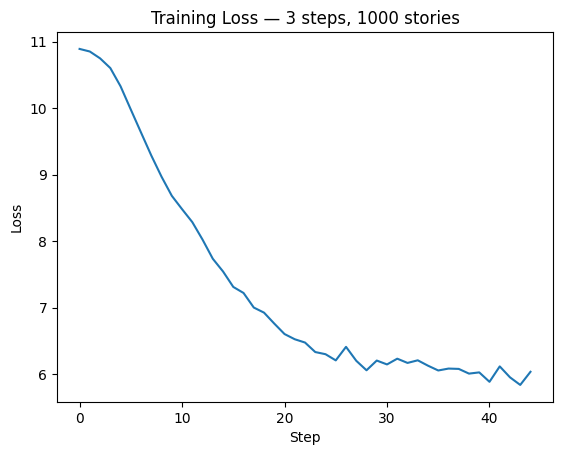

In [15]:
import matplotlib.pyplot as plt
plt.plot(metrics_history['train_loss'])
plt.title('Training Loss — 3 steps, 1000 stories')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
from pathlib import Path 
import orbax # Checkpointing library from Google, works well with JAX/Flax models
# why? Because JAX/Flax models are often represented as PyTrees, which are nested structures of lists, tuples, and dictionaries. 
# Orbax provides a convenient way to save and load these complex structures without needing to manually serialize each component. 


checkpoint_path = Path.cwd() / "small_checkpoint.orbax"

checkpointer = orbax.checkpoint.PyTreeCheckpointer()

checkpointer.save(checkpoint_path, nnx.state(model), force=True)
print(f"Model saved as {checkpoint_path}")

# checkpointing: saving the model's parameters to disk so we can load it later without retraining from scratch.